In [1]:
import numpy as np 
import torch


from xaikd import datasets, models, attributors, utils
from xaikd.utils import metrics

from matplotlib import pyplot as plt

from torch.nn import functional as F

import pandas as pd

In [2]:
DEVICE = utils.get_device()

In [3]:
MODEL_NAME = "cifar100-resnet18-v1"
DATASET_NAME = "cifar100-people"

In [4]:
dataset  = datasets.construct(DATASET_NAME)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [5]:
ds_train = dataset.create_subset(train_split=True)
ds_val = dataset.create_subset(train_split=False)

In [6]:
dl_train = datasets.build_dataloader(ds_train, shuffle=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False)

In [7]:
model = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)
model = model.to(DEVICE)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [8]:
teacher_acc, teacher_xent = metrics.accuracy(model, dl_val, num_classes=5, device=DEVICE)

In [9]:
def construct_logit_modifier(name):
    num_classes = len(dataset.selected_classes)
    if name == "TargetClass":
        return attributors.TargetClassEvidence(num_classes=num_classes)
    elif name == "WinningClass":
        return attributors.WinningClassEvidence(num_classes=num_classes)
    elif name == "DifferenceTop2Winners":
        return attributors.DifferenceTop2WinningClassesEvidence(num_classes=num_classes)
    else:
        raise ValueError
        
        
construct_logit_modifier("DifferenceTop2Winners")

In [10]:
def build_prca_basis(layer, logit_modifier):
    act, ctx = attributors.extract_activation_context(
        model,
        layer,
        dataset=dataset,
        data_loader=dl_train,
        logit_modifier=construct_logit_modifier(logit_modifier),
        rng=np.random.default_rng(seed=1),
        device=DEVICE
    )
    d = act.shape[1]
    
    
    crosscov = (act.T @ ctx  + ctx.T @ act) / act.shape[0]
    assert crosscov.shape == (d, d)
    
    eigvals, eigvecs = np.linalg.eigh(crosscov)
    
    eigvals = np.abs(eigvals)
    
    sorted_indices = np.argsort(-eigvals)
    
    
    
    return eigvecs[:, sorted_indices], eigvals[sorted_indices]

_, eigvals = build_prca_basis("layer3", "DifferenceTop2Winners")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.49it/s]


layer3: output-dims=torch.Size([256, 8, 8])


# Analysis Eigenvalues

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.36it/s]


layer1: output-dims=torch.Size([64, 32, 32])


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.45it/s]


layer1: output-dims=torch.Size([64, 32, 32])


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.36it/s]


...

layer4: output-dims=torch.Size([512, 4, 4])


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.54it/s]


layer4: output-dims=torch.Size([512, 4, 4])


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.50it/s]


layer4: output-dims=torch.Size([512, 4, 4])


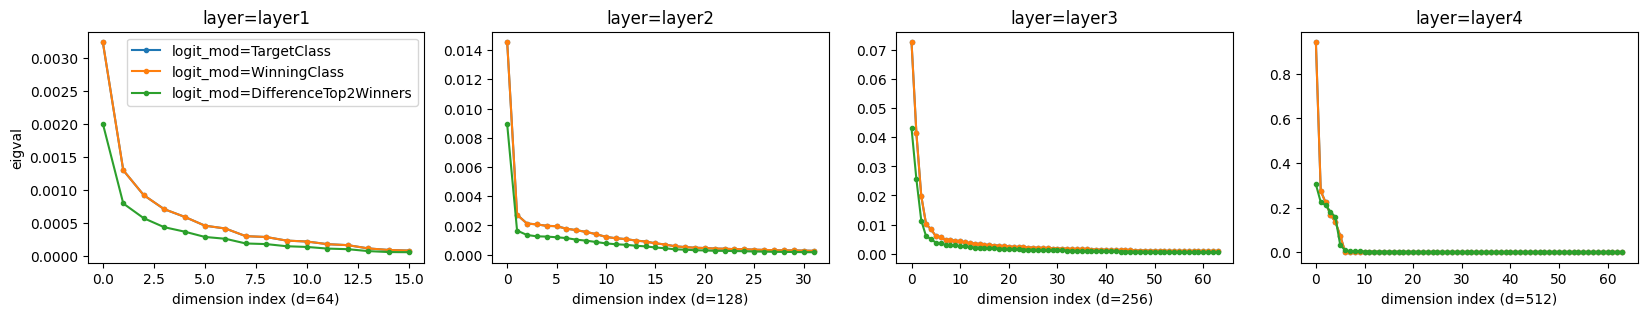

In [11]:
def viz_spectrums(arr_layers):
    
    ncols = len(arr_layers)
    plt.figure(figsize=(5*ncols, 3))
    
    for lix, (layer, factor) in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        
        plt.title(f"layer={layer}")
        for logit_mod in [
            "TargetClass",
            "WinningClass",
            "DifferenceTop2Winners"
        ]:
            _, eigvals = build_prca_basis(layer, logit_mod)
            
            assert len(eigvals.shape) == 1
            
            d = len(eigvals)
            plt.plot(eigvals[:d//factor],  marker=".", label=f"logit_mod={logit_mod}")
        
        
        plt.xlabel(f"dimension index (d={d})")
        if lix == 0:
            plt.ylabel("eigval")
            plt.legend()
viz_spectrums([
    ("layer1", 4),
    ("layer2", 4),
    ("layer3", 4),
    ("layer4", 8),
])

# Looking at Accuracy

In [12]:
def build_pca_basis(layer):
    act, ctx = attributors.extract_activation_context(
        model,
        layer,
        dataset=dataset,
        data_loader=dl_train,
        logit_modifier=construct_logit_modifier("TargetClass"),
        rng=np.random.default_rng(seed=1),
        device=DEVICE
    )
    d = act.shape[1]
    
    
    cov = np.cov(act.T)
    assert cov.shape == (d, d)
    
    eigvals, eigvecs = np.linalg.eigh(cov)
    
    eigvals = np.abs(eigvals)
    
    sorted_indices = np.argsort(-eigvals)
    
    return eigvecs[:, sorted_indices], eigvals[sorted_indices]

_, eigvals = build_pca_basis("layer3")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.40it/s]


layer3: output-dims=torch.Size([256, 8, 8])


In [13]:
CACHE_BASES = dict()

In [14]:
def get_basis(layer, basis_name):
    
    slug = f"{layer}-{basis_name}"
    
    if slug in CACHE_BASES:
        print(f"Using `{slug}` from cache.")
        return CACHE_BASES[slug]
    
    
    print(f"Extract `{basis_name}` from `{layer}`")
    
    
    if basis_name == "pca":
        eigvecs, _ = build_pca_basis(layer)
        
    elif "prca-sortabs" in basis_name:
        logit_mod = basis_name.split(":")[-1]
        eigvecs, _ = build_prca_basis(layer, logit_mod)

    else:
        raise ValueError
        
    CACHE_BASES[slug] = eigvecs
        
    return eigvecs

get_basis("layer3", "prca-sortabs:TargetClass")

Extract `prca-sortabs:TargetClass` from `layer3`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.50it/s]


layer3: output-dims=torch.Size([256, 8, 8])


array([[-0.03273422, -0.00857647, -0.05014271, ...,  0.00883873,
        -0.01439731,  0.01959353],
       [-0.04143532, -0.00620811, -0.07713319, ...,  0.01106522,
        -0.01913188,  0.04025963],
       [-0.0304725 , -0.00447181, -0.0513579 , ..., -0.01183185,
        -0.0232665 , -0.00949137],
       ...,
       [-0.01486302, -0.0158902 , -0.02590747, ...,  0.02763816,
         0.06483232,  0.01859671],
       [-0.05714878, -0.00138701, -0.05213291, ..., -0.01255581,
        -0.00716765, -0.0132407 ],
       [-0.03040163, -0.02782051, -0.03045138, ..., -0.09383361,
        -0.01983384,  0.10285279]], dtype=float32)

Extract `pca` from `layer3`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.48it/s]


layer3: output-dims=torch.Size([256, 8, 8])
Using `layer3-prca-sortabs:TargetClass` from cache.
Extract `prca-sortabs:WinningClass` from `layer3`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.52it/s]


layer3: output-dims=torch.Size([256, 8, 8])
Extract `prca-sortabs:DifferenceTop2Winners` from `layer3`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.46it/s]


layer3: output-dims=torch.Size([256, 8, 8])


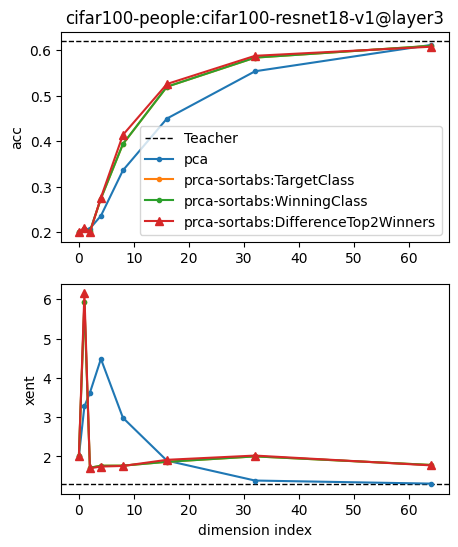

In [15]:
def project_and_reconstruct_at_k(U, k):
    
    
    U = torch.from_numpy(U[:, :k]).float().to(DEVICE)
    
    
    UUt = U@U.T
    UUt = UUt.unsqueeze(2).unsqueeze(3)
    
    
    def forward(mod, inp, out):
        
        out = F.conv2d(out, UUt)
                
        return out

    return forward


def marker(name):
    if "Difference" in name:
        return "^"
    else:
        return "."

def measure_accuracy(layer, arr_basis_names, arr_ks, show_legend=False):
    rows = []
    
    
    teacher_merics = dict(
        acc=teacher_acc,
        xent=teacher_xent
    )
    
    nrows = 2
    
    plt.figure(figsize=(5, nrows*3))
    
    for basis_name in arr_basis_names:

        U = get_basis(layer, basis_name)


        for k in arr_ks:        

            try:

                module = getattr(model, layer)

                hook = module.register_forward_hook(project_and_reconstruct_at_k(U, k))

                acc, xent = metrics.accuracy(
                    model,
                    dl_val, 
                    num_classes=len(dataset.selected_classes),
                    device=DEVICE
                )
                
                rows.append(dict(
                    layer=layer,
                    basis_name=basis_name,
                    k=k,
                    acc=acc,
                    xent=xent,
                ))
            finally:
                hook.remove()

    df = pd.DataFrame(rows)
    
    
    for cix, col in enumerate(["acc", "xent"]):
        plt.subplot(nrows, 1, cix +1)
        plt.axhline(teacher_merics[col], ls="--", color="k", lw=1, label="Teacher")
        for bix, basis_name in enumerate(arr_basis_names):
            _df = df[df.basis_name == basis_name]
            values = _df[col]
            plt.plot(arr_ks, values, label=basis_name, marker=marker(basis_name))

        
        
        plt.ylabel(col)
        if cix == 0:
            plt.title(f"{DATASET_NAME}:{MODEL_NAME}@{layer}")
        if cix == 1:
            plt.xlabel("dimension index")
        if show_legend and cix == 0:
            plt.legend()

measure_accuracy(
    layer="layer3", 
    arr_basis_names=[
        "pca", 
        "prca-sortabs:TargetClass",
        "prca-sortabs:WinningClass",
        "prca-sortabs:DifferenceTop2Winners",
    ], 
    arr_ks=[
        0,
        1,
        2,
        4,
        8,
        16,
        32,
        64
    ],
    show_legend=True
)

Extract `pca` from `layer1`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.39it/s]

layer1: output-dims=torch.Size([64, 32, 32])


Extract `prca-sortabs:TargetClass` from `layer1`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:09<00:00,  4.36it/s]

...

layer4: output-dims=torch.Size([512, 4, 4])
Extract `prca-sortabs:WinningClass` from `layer4`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.52it/s]


layer4: output-dims=torch.Size([512, 4, 4])
Extract `prca-sortabs:DifferenceTop2Winners` from `layer4`


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.52it/s]


layer4: output-dims=torch.Size([512, 4, 4])


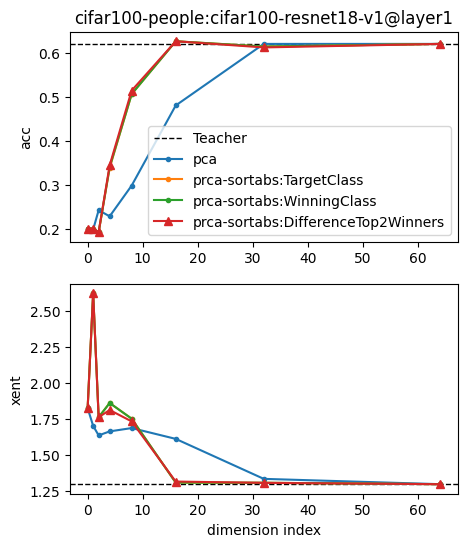

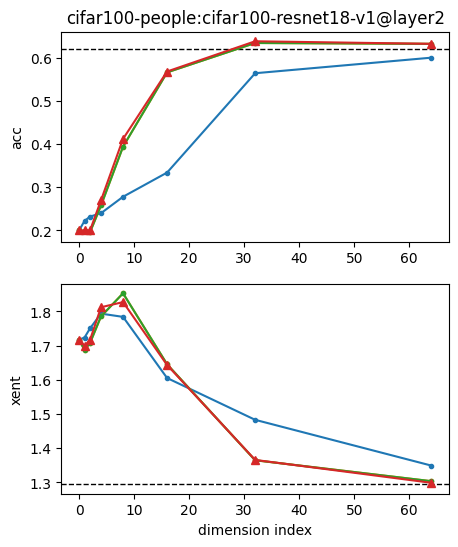

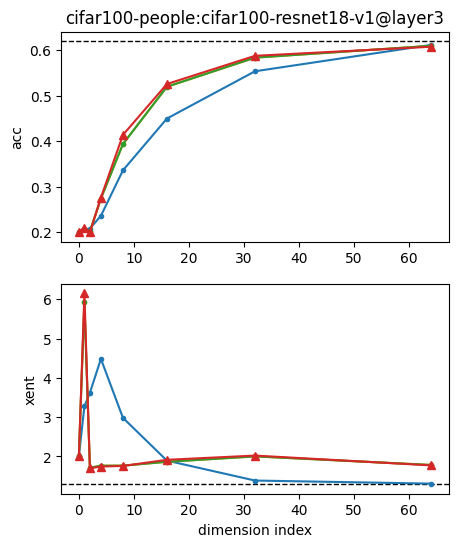

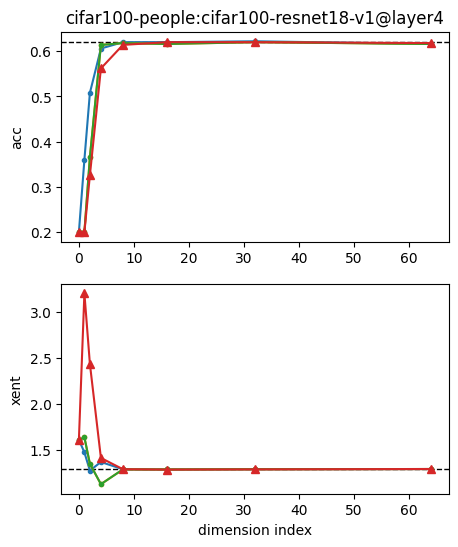

In [16]:
for lix, layer in enumerate(['layer1', 'layer2', 'layer3', 'layer4']):
    measure_accuracy(
    layer=layer, 
    arr_basis_names=[
        "pca", 
        "prca-sortabs:TargetClass",
        "prca-sortabs:WinningClass",
        "prca-sortabs:DifferenceTop2Winners",
    ], 
    arr_ks=[
        0,
        1,
        2,
        4,
        8,
        16,
        32,
        64
    ],
    show_legend=lix == 0
)